
# Retail Sales Performance & Customer Insights

## Exploratory Data Analysis

### Oasis Infobyte — Data Analytics Internship

**Intern:** Yash Jadhav  
**Track:** Data Analytics  
**Task:** Level 1 — EDA on Retail Sales Data                               
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## Project Objective

The objective of this project is to perform exploratory data analysis
on retail sales data to identify sales trends, customer behaviour,
product performance and business opportunities.

## The analysis focuses on:

 - Sales performance over time
 - Customer demographics and segments
 - Product and category performance
 - Regional performance
 - Relationships between numerical variables
 - Actionable business recommendations


## 1. Business Objective

The primary objective of this analysis is to understand the factors
influencing retail sales and profitability.

The analysis aims to answer the following business questions:

1. How do sales change over time?
2. Which customer segments contribute the most revenue?
3. Which products and categories perform best?
4. Which regions generate the highest sales and profit?
5. Is higher sales always associated with higher profitability?
6. How does discounting relate to profit?
7. Which areas present opportunities for business improvement?

The findings will be translated into actionable recommendations for
sales, marketing, inventory, and pricing decisions.

## 2. Data Acquisition & Dataset Overview

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [6]:
ss = pd.read_csv(r"C:\Users\YASH\OneDrive\Desktop\OIBSIP\samplesuperstore.csv")

### Dataset Preview

In [52]:
ss.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Quarter,Day_Name,Shipping_Days
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,16.448,2,0.2,5.5512,2023,1,January,2023Q1,Tuesday,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3.540,2,0.8,-5.4870,2023,1,January,2023Q1,Wednesday,4


In [53]:
ss.tail(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Quarter,Day_Name,Shipping_Days
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,90.930,7,0.0,2.7279,2026,12,December,2026Q4,Wednesday,4
10193,10194,CA-2026-143500,2026-12-30,2027-01-03,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,3.024,3,0.2,-0.6048,2026,12,December,2026Q4,Wednesday,4


## 3. Data Understanding & Initial Inspection

In [9]:
ss.shape

(10194, 21)

In [10]:
ss.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
ss.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

In [12]:
ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [13]:
# Quality Summary -> Data Quality Report
quality_summary = pd.DataFrame({
    "Column": ss.columns,
    "Data Type": ss.dtypes.astype(str).values,
    "Missing Values": ss.isnull().sum().values,
    "Missing %": (ss.isnull().mean() * 100).round(2).values,
    "Unique Values": ss.nunique().values
})

quality_summary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Row ID,int64,0,0.0,10194
1,Order ID,object,0,0.0,5111
2,Order Date,object,0,0.0,1242
3,Ship Date,object,0,0.0,1338
4,Ship Mode,object,0,0.0,4
5,Customer ID,object,0,0.0,804
6,Customer Name,object,0,0.0,800
7,Segment,object,0,0.0,3
8,Country/Region,object,0,0.0,2
9,City,object,0,0.0,542


### Data Quality Findings

The dataset contains 10,194 records across 21 columns.

The data quality assessment shows:

- No missing values were identified.
- No completely duplicated records were identified.
- Sales, Quantity, Discount, and Profit are stored as numerical variables.
- Order Date and Ship Date initially required conversion from object
  format to datetime format.
- Categorical variables are stored appropriately as object/string
  fields.

Based on these checks, no missing-value imputation or duplicate removal
was required. The primary cleaning step involved correcting the date
data types for time-based analysis.


In [19]:
ss.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

## 4. Data Quality Assessment & Cleaning

In [16]:
ss.isnull().sum()
# Checking nulls values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

## 5. Descriptive Statistical Analysis

In [17]:
ss.duplicated().sum()
# Checking for duplicates col

0

In [18]:
ss["Order Date"] = pd.to_datetime(ss["Order Date"])
ss["Ship Date"] = pd.to_datetime(ss["Ship Date"])

In [54]:
numeric_cols = ss.select_dtypes(include=np.number).columns

summary_stats = pd.DataFrame({
    "Mean": ss[numeric_cols].mean(),
    "Median": ss[numeric_cols].median(),
    "Mode": ss[numeric_cols].mode().iloc[0],
    "Standard Deviation": ss[numeric_cols].std()
})

summary_stats

,Mean,Median,Mode,Standard Deviation
Row ID,5097.500000,5097.50,1.00,2942.898656
Sales,228.225854,53.91,12.96,619.906839
Quantity,3.791838,3.00,2.00,2.228317
Discount,0.155385,0.20,0.00,0.206249
Profit,28.673417,8.69,0.00,232.465115
Year,2024.720129,2025.00,2026.00,1.125611
Month,7.811850,9.00,11.00,3.295915
Shipping_Days,3.961350,4.00,4.00,1.742829


### Key Observations

The descriptive statistics provide an overview of the central tendency
and variability of the numerical variables.

- Sales has a mean of approximately 228.23 while the median is 53.91,
  indicating a substantial difference between the two measures.
- Profit has a mean of approximately 28.67 compared with a median of
  8.69, suggesting that the distribution is influenced by higher-value
  observations.
- The average quantity per transaction is approximately 3.79 units.
- The average discount is approximately 15.54%.
- The relatively large standard deviation of Sales compared with its
  median indicates considerable variation in transaction values.

These differences between mean and median suggest that further
distributional analysis is useful before drawing conclusions about
typical transaction behaviour.

## 6. Feature Engineering for Business Analysis

In [20]:
ss["Year"] = ss["Order Date"].dt.year

In [21]:
ss["Month"] = ss["Order Date"].dt.month

In [22]:
ss["Month_Name"] = ss["Order Date"].dt.month_name()

In [23]:
ss["Quarter"] = ss["Order Date"].dt.to_period("Q").astype(str)

In [24]:
ss["Day_Name"] = ss["Order Date"].dt.day_name()

In [25]:
ss["Shipping_Days"] = (ss["Ship Date"] - ss["Order Date"]).dt.days

## 7. Sales Trend & Time-Series Analysis

### 7.1 Monthly Sales Performance

In [26]:
monthly_sales = (
    ss.groupby(ss["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

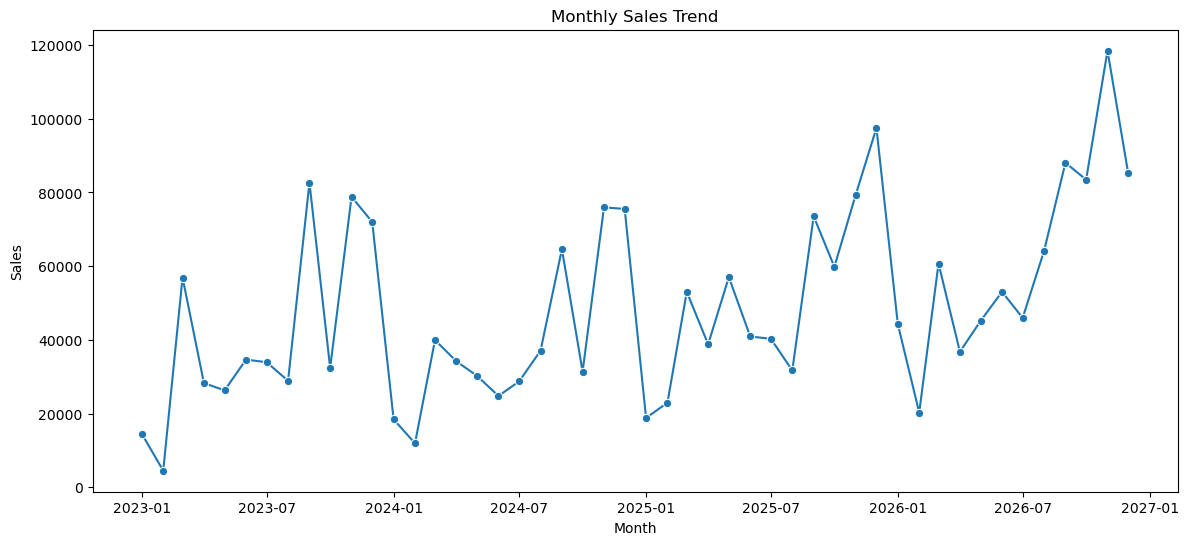

In [27]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="Order Date", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Key Observations

The monthly sales trend reveals how revenue changes throughout the
analysis period.

- Sales fluctuate across months rather than remaining constant.
- Certain periods demonstrate stronger sales activity, indicating
  potential seasonality.
- Periods of lower sales may represent opportunities for targeted
  promotional campaigns.

### Business Implication

Understanding monthly demand patterns can help the business improve
inventory planning, promotional timing, and resource allocation.

### 7.2 Quarterly Sales Performance

In [28]:
quarterly_sales = (ss.groupby("Quarter")["Sales"].sum().reset_index())

In [29]:
quarterly_sales

,Quarter,Sales
0,2023Q1,75971.8560
1,2023Q2,89284.5916
2,2023Q3,145535.1603
3,2023Q4,183248.6042
4,2024Q1,70391.9546
5,2024Q2,89239.4470
6,2024Q3,130449.3752
7,2024Q4,182912.2542
8,2025Q1,94840.2150
9,2025Q2,136809.1450


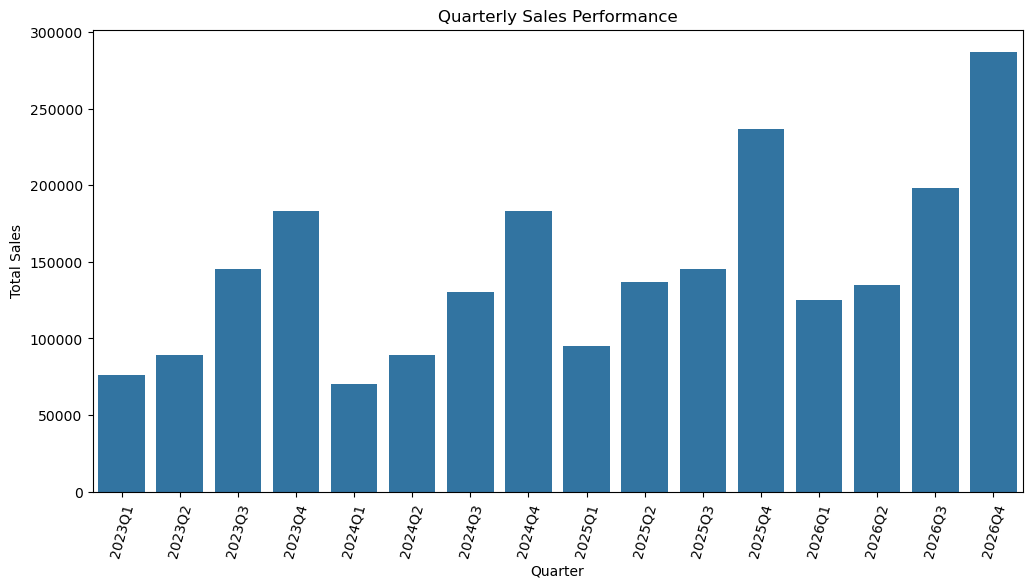

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_sales, x="Quarter", y="Sales")
plt.title("Quarterly Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation = 75)
plt.show()

### Key Observations

Quarterly aggregation provides a broader view of sales performance and
reduces the noise present in individual monthly observations.

The comparison highlights the strongest and weakest quarters and helps
identify periods where sales activity is concentrated.

### Business Implication

Quarterly sales patterns can support strategic planning for inventory,
marketing budgets, and sales targets.

## 8. Customer & Segment Analysis

### 8.1 Sales by Customer Segment

In [31]:
segment_sales = (ss.groupby("Segment")["Sales"].sum().sort_values(ascending=False))
segment_sales

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64

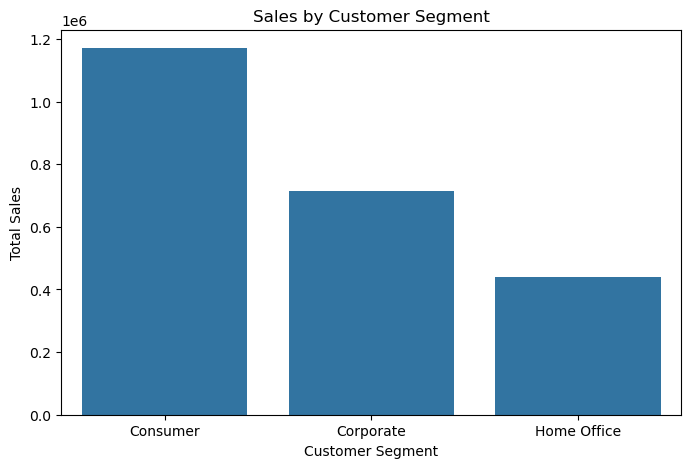

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

### Key Observations

The customer segment analysis compares sales contribution across the
available customer segments.

The results help identify which customer groups generate the largest
share of revenue and therefore deserve greater attention in customer
retention and marketing strategies.

### Business Implication

Customer segments with strong revenue contribution can be targeted with
retention programs, personalized offers, and loyalty initiatives.

## 9. Product & Category Performance Analysis

### 9.1 Top 10 Products by Sales

In [33]:
top_products = (ss.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10))

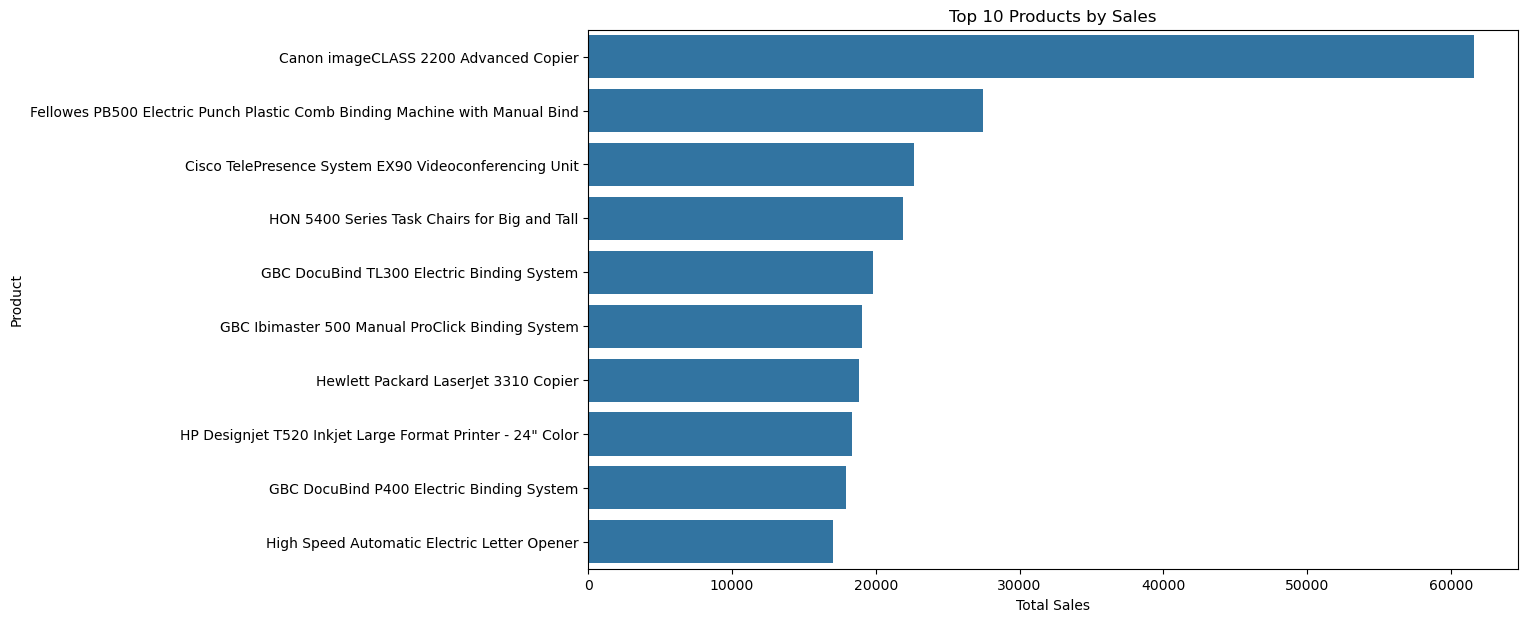

In [34]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

### Key Observations

The top-performing products contribute significantly to overall sales
and provide insight into products with strong customer demand.

These products can be evaluated further based on their profitability,
quantity sold, and discount levels to determine whether high sales are
also generating healthy returns.

### 9.2 Category-Level Performance

In [35]:
category_sales = (ss.groupby("Category")["Sales"].sum().sort_values(ascending=False))
category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

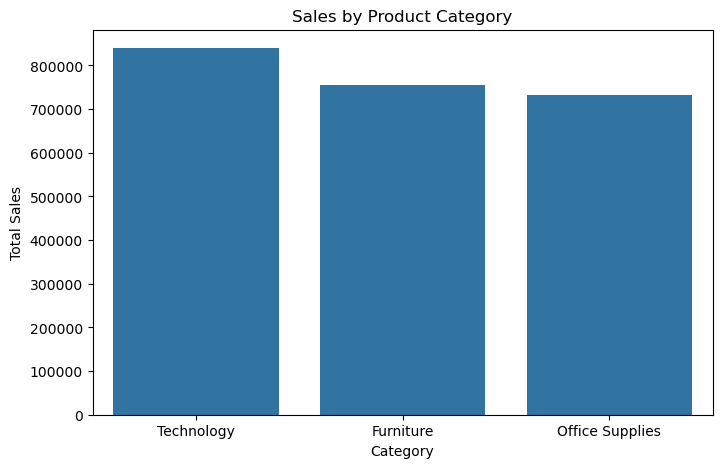

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Key Observations

Category-level analysis compares Sales, Profit, Quantity, and Average
Discount to provide a more complete view of category performance.

Sales alone do not provide a complete picture of business performance.
A category may generate high revenue while producing comparatively
lower profit margins.

Therefore, category decisions should consider both revenue generation
and profitability.

## 10. Profitability & Discount Analysis

In [37]:
category_performance = (
    ss.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Avg_Discount=("Discount", "mean")
      )
      .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit,Quantity,Avg_Discount
Category,,,,
Technology,839893.2790,146543.3756,7017,0.131475
Furniture,754747.7613,19729.9956,8369,0.172962
Office Supplies,731893.3140,126023.4434,23268,0.156348


In [38]:
category_performance["Profit_Margin_%"] = (
    category_performance["Profit"] /
    category_performance["Sales"] * 100
)

category_performance

,Sales,Profit,Quantity,Avg_Discount,Profit_Margin_%
Category,,,,,
Technology,839893.2790,146543.3756,7017,0.131475,17.447857
Furniture,754747.7613,19729.9956,8369,0.172962,2.614118
Office Supplies,731893.3140,126023.4434,23268,0.156348,17.218827


In [43]:
profit_category = (ss.groupby("Category")["Profit"].sum().sort_values(ascending=False))

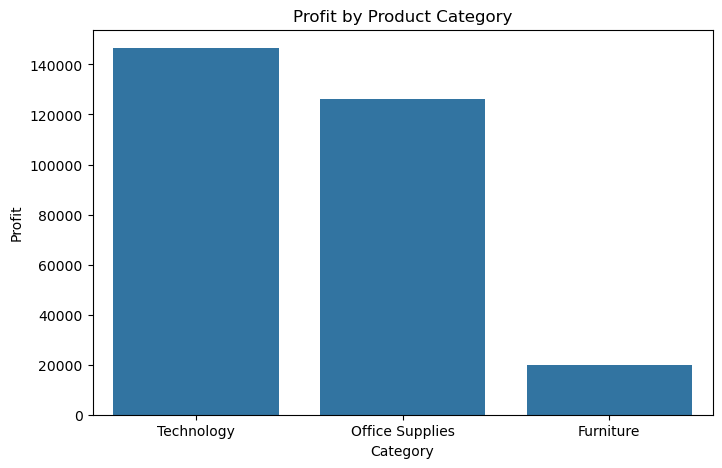

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_category.index, y=profit_category.values)
plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## 11. Regional Sales & Profitability Analysis

### 11.1 Sales by Region

In [46]:
region_sales = (ss.groupby("Region")["Sales"].sum().sort_values(ascending=False))

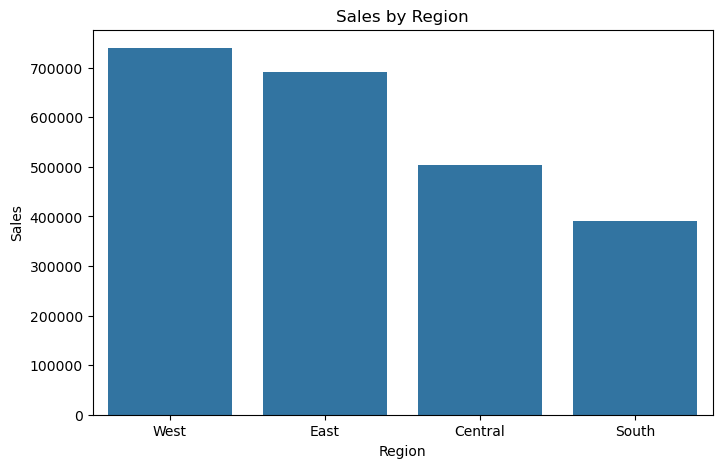

In [47]:
plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

### 11.2 Profit by Region

In [48]:
region_profit = (ss.groupby("Region")["Profit"].sum().sort_values(ascending=False))

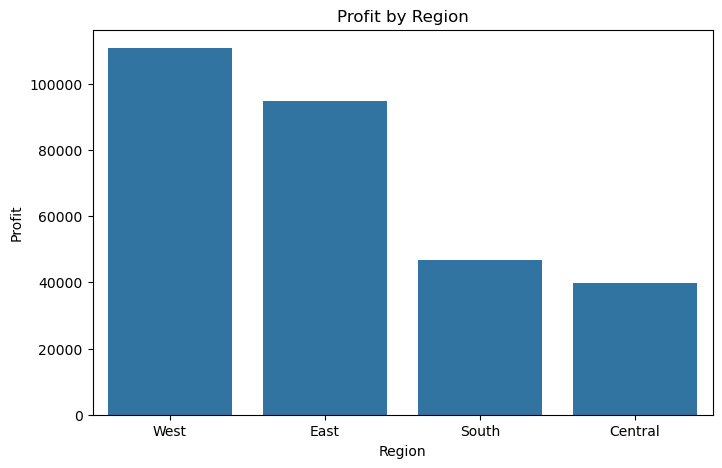

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

### Key Observations

Regional performance varies across both sales and profitability.

Comparing sales and profit together helps identify regions that are
strong revenue contributors as well as regions where sales may not
translate into proportionate profit.

### Business Implication

Regional strategies should consider both revenue and profitability,
rather than focusing exclusively on sales volume.

## 13. Relationship Between Numerical Variables

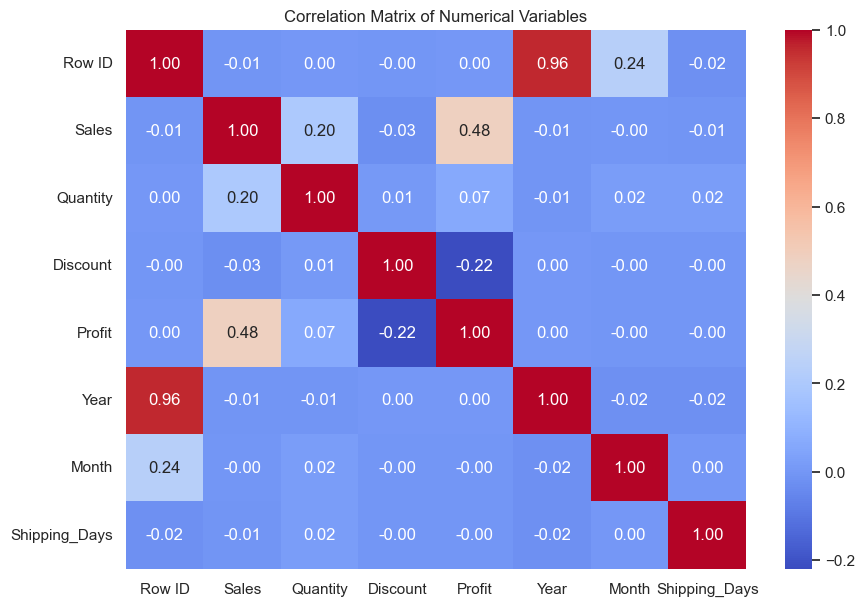

In [113]:
numeric_data = ss.select_dtypes(include=np.number)
correlation = numeric_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Key Observations

The correlation matrix summarizes the relationships among numerical
variables including Sales, Quantity, Discount, Profit, and other
numeric features.

Correlation indicates the strength and direction of a linear
relationship between variables; however, correlation alone does not
establish causation.

The results should therefore be interpreted alongside the individual
sales, profit, and discount analyses.

## 14. Discount vs Profit

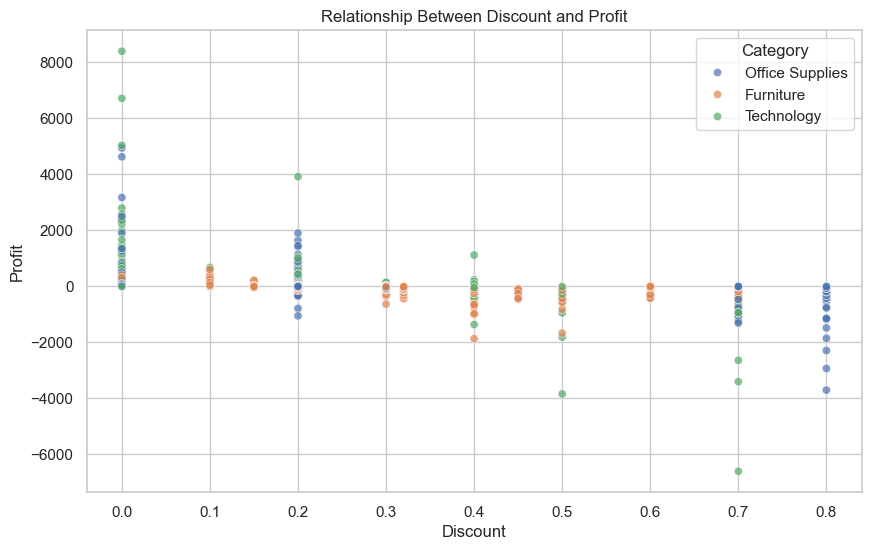

In [114]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ss,x="Discount",y="Profit",hue="Category",alpha=0.7)
plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

### Key Observations

The relationship between discount and profit is examined to understand
whether higher discount levels are associated with reduced
profitability.

The scatter plot shows substantial variation in profit across different
discount levels, with some heavily discounted transactions producing
low or negative profit.

### Business Implication

Discount strategies should be evaluated at the product or
sub-category level rather than applied uniformly. High discounts that
do not generate sufficient additional sales may reduce overall
profitability.

# Executive Summary

This exploratory data analysis examined **10,194 retail transaction
records across 21 variables** to understand sales performance,
customer behaviour, product performance, regional trends, and
profitability.

### 📈 Sales Performance

The time-series analysis highlights variations in sales across months
and quarters, indicating periods of stronger and weaker business
activity. These patterns can support more effective sales forecasting,
inventory planning, and promotional scheduling.

### 👥 Customer Insights

Customer segment analysis identifies the relative contribution of
different customer groups to overall sales. Understanding these
differences can help the business prioritize customer retention and
targeted marketing initiatives.

### 📦 Product & Category Performance

Product and category analysis highlights the products and categories
responsible for a significant share of sales. However, sales volume
alone does not fully represent performance, making the comparison with
profit and profit margin particularly important.

### 💰 Profitability

The profitability analysis demonstrates the importance of evaluating
sales alongside profit, discount levels, and profit margins. Some
transactions may generate strong revenue while contributing relatively
little profit.

### 🌎 Regional Performance

Regional analysis provides insight into differences in sales and
profitability across geographical markets. This can support
region-specific sales and marketing strategies.

### 🚚 Operational Performance

Shipping analysis provides an additional perspective on operational
efficiency by comparing delivery duration across shipping modes.

---

## Key Business Takeaways

1. **Revenue and profitability should be evaluated together.**
2. **Discount strategies should be monitored carefully because high
   discounts can negatively affect profitability.**
3. **Seasonal sales patterns can be used to improve inventory and
   promotional planning.**
4. **High-value customers and strong-performing product categories
   should receive greater retention and marketing attention.**
5. **Regional performance should be evaluated using both sales and
   profitability rather than revenue alone.**

# Conclusion

This project used exploratory data analysis to examine retail sales
performance from multiple business perspectives, including time-based
sales trends, customer segments, product categories, regional
performance, profitability, discounts, and shipping operations.

The analysis demonstrates that retail performance cannot be evaluated
using sales revenue alone. Combining sales with profit, quantity,
discount, customer, product, regional, and operational information
provides a more comprehensive understanding of business performance.

The analysis also highlights the importance of identifying seasonal
sales patterns, understanding high-value customers, evaluating product
and category profitability, and monitoring the relationship between
discounting and profit.

## Business Recommendations

### 1. Optimize Discount Strategies

Review products and sub-categories where high discounts are associated
with low or negative profitability. Discount levels should be aligned
with products' margins and demand rather than applied uniformly.

### 2. Strengthen High-Performing Categories

Prioritize inventory, marketing, and promotional resources toward
categories and products that demonstrate strong sales combined with
healthy profitability.

### 3. Improve Seasonal Planning

Use historical monthly and quarterly sales patterns to prepare
inventory and promotional campaigns ahead of high-demand periods.

### 4. Focus on Customer Retention

Identify high-value customers and strengthen retention strategies
through loyalty programs, personalized offers, and targeted marketing.

### 5. Develop Region-Specific Strategies

Evaluate each region based on both sales and profit performance and
design targeted strategies for high-potential and underperforming
markets.

### 6. Monitor Operational Efficiency

Use shipping-duration analysis to evaluate delivery performance and
identify opportunities to improve customer experience while
maintaining operational efficiency.

---

## Final Takeaway

The analysis converts raw transactional data into actionable business
insights and demonstrates how exploratory data analysis can support
data-driven decisions across sales, marketing, pricing, customer
retention, inventory planning, and operations.